# Questão 5

Compressão da imagem `sosias.jpg` por blocos `L x L`, com `L` em `{8, 64}`
e preservação de energia em `{95%, 50%}` por bloco.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dctn, idctn
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()

def find_repo_root(start_path):
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'data').exists() and (candidate / 'pratica_4').exists():
            return candidate
    raise FileNotFoundError(
        'Repositorio nao encontrado. Execute o notebook dentro da pasta do projeto.'
    )

REPO_ROOT = find_repo_root(CWD)
PRACTICE_DIR = REPO_ROOT / 'pratica_4'
DATA_DIR = REPO_ROOT / 'data'

def find_image():
    candidates = [
        PRACTICE_DIR / 'sosias.jpg',
        DATA_DIR / 'sosias.jpg',
        DATA_DIR / 'sosias.jpeg',
        DATA_DIR / 'sosias.png',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        'Imagem sosias.jpg nao encontrada. Coloque o arquivo em pratica_4/ ou data/.'
    )


In [2]:
def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))
def select_by_energy(coeffs, keep_energy):
    coeffs = np.asarray(coeffs)
    energy = np.abs(coeffs) ** 2
    flat_energy = energy.ravel()
    order = np.argsort(flat_energy)[::-1]
    cumulative = np.cumsum(flat_energy[order])
    total_energy = cumulative[-1]
    threshold = keep_energy * total_energy
    keep_count = int(np.searchsorted(cumulative, threshold, side='left')) + 1

    mask = np.zeros(coeffs.size, dtype=bool)
    mask[order[:keep_count]] = True
    mask = mask.reshape(coeffs.shape)

    compressed = np.zeros_like(coeffs)
    compressed[mask] = coeffs[mask]
    retained = float(np.sum(np.abs(compressed) ** 2) / total_energy)
    return compressed, keep_count, retained
def load_gray_image():
    image_path = find_image()
    image = Image.open(image_path).convert('L')
    return image_path, np.asarray(image, dtype=np.float64) / 255.0


def compress_image_dct(image_array, keep_energy):
    coeffs = dctn(image_array, norm='ortho')
    compressed, keep_count, retained = select_by_energy(coeffs, keep_energy)
    reconstructed = idctn(compressed, norm='ortho')
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    return coeffs, reconstructed, keep_count, retained


def blockwise_dct_compression(image_array, block_size, keep_energy):
    h, w = image_array.shape
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size
    padded = np.pad(image_array, ((0, pad_h), (0, pad_w)), mode='edge')
    reconstructed = np.zeros_like(padded)
    total_kept = 0

    for i in range(0, padded.shape[0], block_size):
        for j in range(0, padded.shape[1], block_size):
            block = padded[i:i + block_size, j:j + block_size]
            coeffs = dctn(block, norm='ortho')
            compressed, keep_count, _ = select_by_energy(coeffs, keep_energy)
            reconstructed[i:i + block_size, j:j + block_size] = idctn(compressed, norm='ortho')
            total_kept += keep_count

    reconstructed = np.clip(reconstructed[:h, :w], 0.0, 1.0)
    return reconstructed, total_kept, total_kept / padded.size


In [3]:
image_path, image = load_gray_image()
keep_levels = [0.95, 0.50]
block_sizes = [8, 64]
results = {}
rows = []

print(f'Imagem usada: {image_path}')

for block_size in block_sizes:
    results[block_size] = {}
    for keep in keep_levels:
        label = f'{keep * 100:.0f}%'
        reconstructed, keep_count, ratio = blockwise_dct_compression(
            image, block_size=block_size, keep_energy=keep
        )
        results[block_size][label] = reconstructed
        rows.append(
            {
                'Bloco': f'{block_size}x{block_size}',
                'Energia': label,
                'Coeficientes mantidos': keep_count,
                'Percentual de coeficientes': 100 * ratio,
                'MSE': mse(image, reconstructed),
            }
        )

display_rows(rows, float_digits=8)


Imagem usada: C:\Users\pedro\OneDrive - cefet-rj.br\Faculdade\Processamento-de-Sinais-1\data\sosias.jpg
Bloco | Energia | Coeficientes mantidos | Percentual de coeficientes | MSE       
------+---------+-----------------------+----------------------------+-----------
8x8   | 95%     | 20329                 | 2.52095734                 | 0.00196647
8x8   | 50%     | 12643                 | 1.56783234                 | 0.00630627
64x64 | 95%     | 3339                  | 0.39004093                 | 0.00889704
64x64 | 50%     | 218                   | 0.02546539                 | 0.03642803


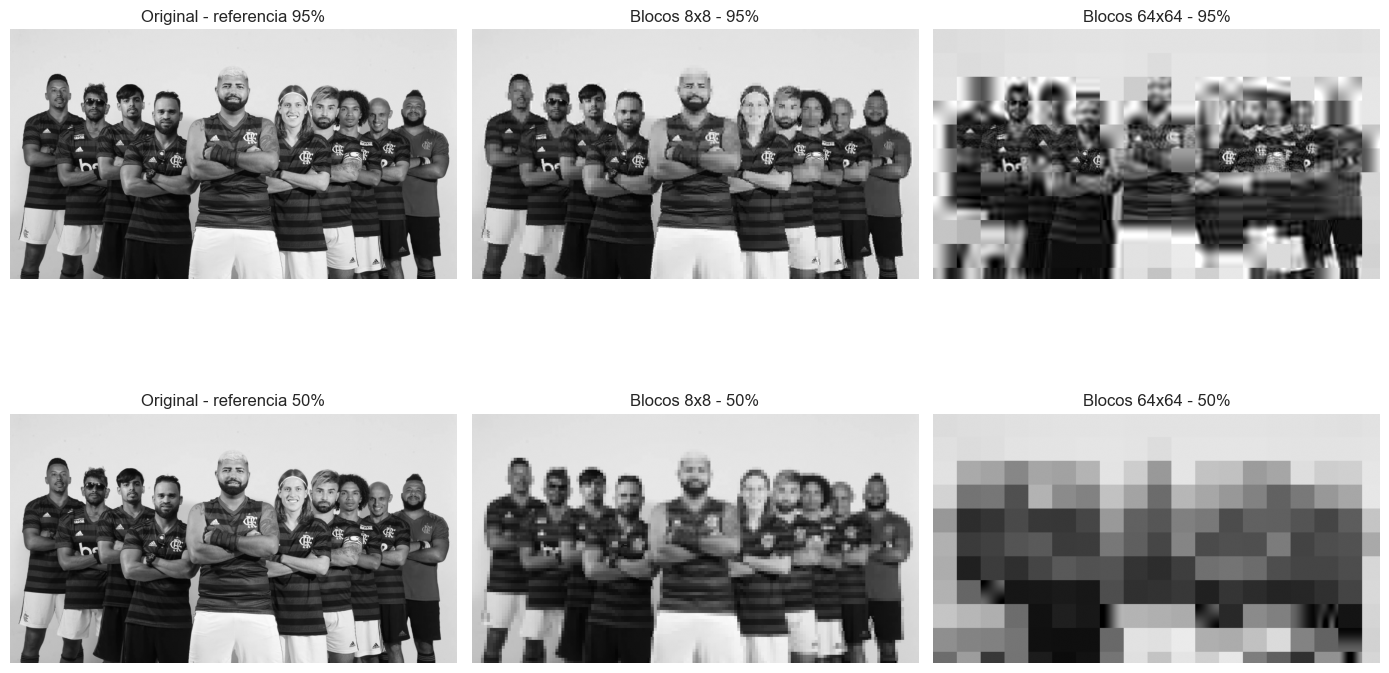

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
labels = ['95%', '50%']

for row_idx, label in enumerate(labels):
    axes[row_idx, 0].imshow(image, cmap='gray', vmin=0, vmax=1)
    axes[row_idx, 0].set_title(f'Original - referencia {label}')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(results[8][label], cmap='gray', vmin=0, vmax=1)
    axes[row_idx, 1].set_title(f'Blocos 8x8 - {label}')
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(results[64][label], cmap='gray', vmin=0, vmax=1)
    axes[row_idx, 2].set_title(f'Blocos 64x64 - {label}')
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()


## Comentários

- Blocos menores costumam preservar melhor detalhes locais, mas podem introduzir blocagem mais visível.
- Blocos maiores tendem a capturar estruturas mais amplas, porém podem degradar regiões inteiras de uma vez.
- A redução para `50%` de energia deixa a perda visual mais evidente do que `95%`.
